# Fuente 3: Mortalidad — INEGI, Estadísticas de Defunciones Registradas (EDR)

Este notebook cubre, para la tercera fuente del proyecto (mortalidad), lo mismo que `01_exploracion_inicial.ipynb` y `02_limpieza_y_union.ipynb` ya hicieron para clima y calidad del aire: **primera extracción** (código que obtiene los datos, primeras filas, dimensiones, tipos) y **diagnóstico inicial** (nulos, duplicados, problemas conocidos).

**Origen:** INEGI — Estadísticas de Defunciones Registradas (EDR), https://www.inegi.org.mx/programas/edr/#microdatos

**Método de acceso:** descarga manual (no hay una URL de descarga directa estable por año; el portal requiere navegar el catálogo). Es una fuente de descarga documentada, igual que el CSV de Kaggle usado para clima.

**Formato:** DBF (formato dBASE). INEGI publica los microdatos anuales en este formato, no en CSV; el notebook los lee con la librería `dbfread`.

**Variables principales:** `ent_ocurr` (entidad de ocurrencia, 09 = Ciudad de México), `anio_ocur`/`mes_ocurr`/`dia_ocurr` (fecha de la defunción), `causa_def` (causa básica, código CIE-10).

**Periodo disponible:** serie anual 1990–2024; el año más reciente se publica con ~10–14 meses de rezago administrativo.

**Prerrequisito para ejecutar este notebook:** descargar al menos un archivo anual de microdatos (botón "DBF" en la tabla de la pestaña "Microdatos") y colocarlo en `data/raw/defunciones_<año>.dbf` (ver `README.md`, sección "Obtener los datos de mortalidad"). No se sube al repositorio por su tamaño y porque son datos públicos descargables por cualquier persona.

## 1. Primera extracción: cargar el microdato crudo

In [7]:
import sys
from pathlib import Path

import pandas as pd

# Permite importar los modulos de src/ (este notebook vive en notebooks/,
# un nivel por debajo de la raiz del repositorio). Todas las rutas de datos
# son relativas a la raiz del repositorio, no a la computadora de un integrante.
sys.path.append(str(Path.cwd().parent))

from src.processing.procesar_mortalidad_inegi import (
    CLAVE_ENTIDAD_CDMX,
    cargar_defunciones,
    clasificar_causa,
)

RUTA_CRUDO = "../data/raw/defunciones_2024.dbf"  # ajustar al archivo descargado

df_crudo = cargar_defunciones(RUTA_CRUDO)
df_crudo.columns = df_crudo.columns.str.lower()  # DBF suele traer los nombres en mayusculas

print("Dimensiones:", df_crudo.shape)
df_crudo.head()

Dimensiones: (819672, 74)


,ent_regis,mun_regis,tloc_regis,loc_regis,ent_resid,mun_resid,tloc_resid,loc_resid,ent_ocurr,mun_ocurr,...,complicaro,dia_cert,mes_cert,anio_cert,maternas,ent_ocules,mun_ocules,loc_ocules,razon_m,dis_re_oax
0,01,002,5,0001,01,001,15,0001,01,005,...,8,23,1,2024,,88,888,8888,NaN,999
1,01,002,5,0059,01,002,1,0015,01,001,...,8,17,1,2024,,88,888,8888,NaN,999
2,01,003,8,0001,01,003,5,0055,01,001,...,8,12,1,2024,,88,888,8888,NaN,999
3,01,003,8,0001,01,003,2,0033,01,003,...,8,17,1,2024,,88,888,8888,NaN,999
4,01,002,5,0001,01,001,15,0001,01,001,...,9,14,12,2023,,88,888,8888,NaN,999


In [8]:
df_crudo.dtypes

ent_regis      object
mun_regis      object
tloc_regis      int64
loc_regis      object
ent_resid      object
               ...   
ent_ocules     object
mun_ocules     object
loc_ocules     object
razon_m       float64
dis_re_oax     object
Length: 74, dtype: object

## 2. Filtrar a la Ciudad de México

In [9]:
df_crudo["ent_ocurr"] = pd.to_numeric(df_crudo["ent_ocurr"], errors="coerce")
df_cdmx = df_crudo[df_crudo["ent_ocurr"] == CLAVE_ENTIDAD_CDMX].copy()

print("Defunciones totales en el archivo:", len(df_crudo))
print("Defunciones de la Ciudad de Mexico:", len(df_cdmx))
df_cdmx.head()

Defunciones totales en el archivo: 819672
Defunciones de la Ciudad de Mexico: 80574


,ent_regis,mun_regis,tloc_regis,loc_regis,ent_resid,mun_resid,tloc_resid,loc_resid,ent_ocurr,mun_ocurr,...,complicaro,dia_cert,mes_cert,anio_cert,maternas,ent_ocules,mun_ocules,loc_ocules,razon_m,dis_re_oax
127904,09,015,15,0001,09,010,15,0001,9,010,...,2,31,12,2024,,99,999,9999,NaN,999
127905,09,015,15,0001,09,017,14,0001,9,017,...,8,31,12,2024,,99,999,9999,NaN,999
127906,09,015,15,0001,09,007,17,0001,9,007,...,8,3,12,2024,,99,999,9999,NaN,999
127907,09,007,17,0001,09,007,17,0001,9,007,...,8,20,12,2024,,88,888,8888,NaN,999
127908,09,015,15,0001,09,003,15,0001,9,003,...,8,27,12,2024,,99,999,9999,NaN,999


## 3. Diagnóstico inicial

Revisión de valores faltantes, duplicados y problemas conocidos en las columnas clave para construir la serie diaria (fecha y causa).

In [10]:
columnas_clave = ["anio_ocur", "mes_ocurr", "dia_ocurr", "causa_def"]

print("Valores faltantes en columnas clave:")
print(df_cdmx[columnas_clave].isna().sum())

print("\nRegistros duplicados completos:", df_cdmx.duplicated().sum())

# INEGI usa el codigo 99 para dia/mes no especificado: revisamos cuantos casos hay.
dias_no_especificados = (df_cdmx["dia_ocurr"] == 99).sum()
meses_no_especificados = (df_cdmx["mes_ocurr"] == 99).sum()
print(f"\nRegistros con dia_ocurr = 99 (no especificado): {dias_no_especificados}")
print(f"Registros con mes_ocurr = 99 (no especificado): {meses_no_especificados}")

Valores faltantes en columnas clave:
anio_ocur    0
mes_ocurr    0
dia_ocurr    0
causa_def    0
dtype: int64

Registros duplicados completos: 2

Registros con dia_ocurr = 99 (no especificado): 3
Registros con mes_ocurr = 99 (no especificado): 3


In [11]:
# Clasificacion de la causa basica de defuncion en capitulo CIE-10
df_cdmx["grupo_causa"] = df_cdmx["causa_def"].astype(str).apply(clasificar_causa)
df_cdmx["grupo_causa"].value_counts()

grupo_causa
otra              49236
cardiovascular    22399
respiratoria       8939
Name: count, dtype: int64

## 4. Primera evidencia: ¿cuántas defunciones respiratorias y cardiovasculares hay al mes?

Una agregación sencilla para responder una primera pregunta descriptiva antes de pasar al análisis de rezago (`notebooks/06_mortalidad_rezago_cdmx.ipynb`).

<Axes: title={'center': 'Defunciones mensuales en CDMX por grupo de causa'}, xlabel='mes'>

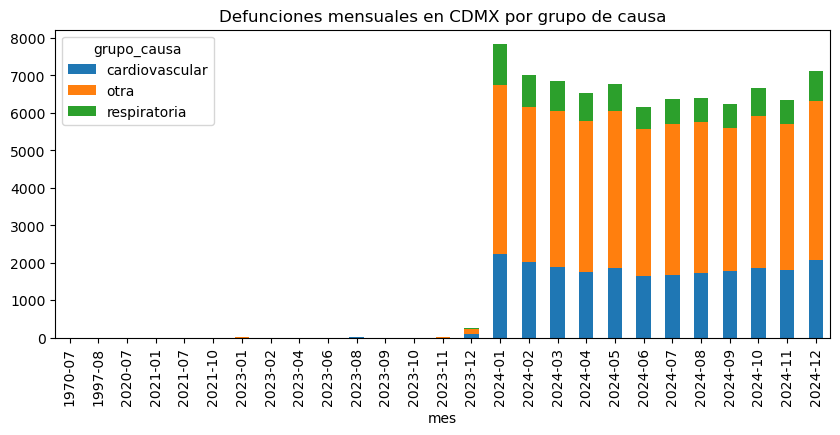

In [12]:
df_cdmx["fecha"] = pd.to_datetime(
    dict(year=df_cdmx["anio_ocur"], month=df_cdmx["mes_ocurr"], day=df_cdmx["dia_ocurr"]),
    errors="coerce",
)

conteo_mensual = (
    df_cdmx.dropna(subset=["fecha"])
    .assign(mes=lambda df: df["fecha"].dt.to_period("M"))
    .groupby(["mes", "grupo_causa"])
    .size()
    .unstack(fill_value=0)
)

conteo_mensual.plot(kind="bar", stacked=True, figsize=(10, 4), title="Defunciones mensuales en CDMX por grupo de causa")

**Interpretación (completar al ejecutar con datos reales):** ¿las defunciones respiratorias muestran algún patrón estacional (p. ej. más altas en meses fríos)? ¿Se mantiene estable el total mensual o hay meses atípicos?

## 5. Próximo paso

Repetir esta extracción para cada año descargado y usar `src/processing/procesar_mortalidad_inegi.py` para generar el conteo diario consolidado (`data/CDMX_mortalidad_diaria.csv`), que alimenta el panel de `src/processing/construir_panel_cdmx.py` y el análisis de rezago en `notebooks/06_mortalidad_rezago_cdmx.ipynb`.